In [1]:
import sys; sys.path.append('../..')
from abstraction.tokenize import *
from abstraction.book_history import *
import pandas as pd
import plotnine as p9
from tqdm import tqdm
from warnings import filterwarnings
filterwarnings('ignore')
p9.options.dpi = 300
p9.options.figure_size=(10,6)

In [2]:
df = pd.read_csv('/Volumes/diderot/lltk_data/corpora/estc/metadata2.csv').fillna('')
df['has_text'] = [bool(x or y) for x,y in zip(df.id_eebo, df.id_ecco)]
df['marked_fiction'] = [is_fiction(form, subject_topic) for form, subject_topic in zip(df.form, df.subject_topic)]
df

,_llp_,author,author_dates,book_dimensions,book_dimensions_standard,book_extent,book_extent_num_pages,corpus,form,form_marc,...,format_secondary,format_cm,num_pages,num_volumes,has_plates,extent_type,id_eebo,id_ecco,has_text,marked_fiction
0,estc|000/N000454,"Willoughby de Broke, Richard Verney",Lord,2⁰,2,"2],6p.",6.0,ESTC,,|,...,,,8.0,,False,pages,,,False,False
1,estc|000/N007437,,,12⁰,2,"52],204p.",204.0,ESTC,,|,...,,,256.0,,False,pages,,,False,False
2,estc|000/N012798,"Malton, Thomas",,8⁰,8,"8],viii,408,32p.",408.0,ESTC,,|,...,,,456.0,,False,pages,,,False,False
3,estc|000/N017166,"St. John, John",,12⁰,2,"vii,[5],47,[1]p.",47.0,ESTC,,|,...,,,60.0,,False,pages,,SSAndFineArt/1105801300,True,False
4,estc|000/N023416,,,12⁰,2,"4],xii,115,[1]p.",115.0,ESTC,Fiction,|,...,,,132.0,,False,pages,,LitAndLang1/0214002400,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481706,estc|fff/W030659,,,4⁰,4,6p.,6.0,ESTC,,|,...,,,6.0,,False,pages,,,False,False
481707,estc|fff/W034085,"Newton, John",,12⁰,2,"6], 372 p.",372.0,ESTC,,|,...,,,378.0,,False,pages,,,False,False
481708,estc|fff/W041984,,,8⁰,8,"p. [4], 40, [2]",40.0,ESTC,,|,...,,,42.0,,False,pages,,,False,False
481709,estc|fff/W042175,,,1/2⁰,2,1 sheet,1.0,ESTC,,|,...,,,1.0,,False,sheet,,,False,False


In [3]:
from collections import Counter
counter = Counter()
stopwords = get_stopwords()

def tokz(x):
    return [x for x in tokenize_agnostic(x.lower()) if x.strip() and x[0].isalpha()]

for title,subtitle in tqdm(zip(df.title,df.title_sub), total=len(df)):
    if title:
        counter.update(tokz(title))
    if subtitle:
        counter.update(tokz(subtitle))

s=pd.Series(counter).sort_values(ascending=False)
sdf = pd.DataFrame({'count':s}).rename_axis('word')
sdf['rank'] = sdf['count'].rank(method='min', ascending=False)
sdf

100%|██████████| 481711/481711 [00:08<00:00, 59495.17it/s]


,count,rank
word,,
the,1688912,1.0
of,1369687,2.0
and,772463,3.0
in,437143,4.0
a,435530,5.0
...,...,...
chleis,1,130223.0
incriptions,1,130223.0
coresponpant,1,130223.0


In [4]:
genredf = pd.read_excel('../data/fields/genre_terms.xlsx').set_index('word')
genredf = genredf[genredf.is_fiction=='y']
genredf = genredf.join(sdf, how='left').sort_values('count', ascending=False)
# genredf.sort_values('count', ascending=False).head(100)
# genredf.sort_values('count', ascending=False).head(100).to_csv('genre_counts_sorted.csv', index=False)
# !open .
genredf

,lemma,genre,is_genre,is_fiction,count,rank
word,,,,,,
history,history,History,NaN,y,19898,82.0
life,life,Life,NaN,y,19487,84.0
dialogue,dialogue,Dialogue,NaN,y,3716,567.0
narrative,narrative,Narrative,NaN,y,3318,634.0
lives,life,Life,NaN,y,2989,704.0
adventures,adventure,Adventures,y,y,2951,714.0
confession,confession,Confession,NaN,y,2227,921.0
tale,tale,Tale,NaN,y,1805,1086.0
dialogues,dialogue,Dialogue,NaN,y,1673,1166.0


In [5]:
o = []
for i,row in tqdm(df.iterrows(), total=len(df)):
    toks = tokz(row.title + ' ' + row.title_sub)
    found = False
    for t in toks:
        if t in genredf.index:
            outd = {
                'word':t,
                **row.to_dict()
            }
            o.append(outd)
            found = True
    if not found:
        outd = {
            'word':'',
            **row.to_dict()
        }
        o.append(outd)
odf = pd.DataFrame(o)
odf

100%|██████████| 481711/481711 [00:31<00:00, 15155.67it/s]


,word,_llp_,author,author_dates,book_dimensions,book_dimensions_standard,book_extent,book_extent_num_pages,corpus,form,...,format_secondary,format_cm,num_pages,num_volumes,has_plates,extent_type,id_eebo,id_ecco,has_text,marked_fiction
0,,estc|000/N000454,"Willoughby de Broke, Richard Verney",Lord,2⁰,2,"2],6p.",6.0,ESTC,,...,,,8.0,,False,pages,,,False,False
1,,estc|000/N007437,,,12⁰,2,"52],204p.",204.0,ESTC,,...,,,256.0,,False,pages,,,False,False
2,,estc|000/N012798,"Malton, Thomas",,8⁰,8,"8],viii,408,32p.",408.0,ESTC,,...,,,456.0,,False,pages,,,False,False
3,,estc|000/N017166,"St. John, John",,12⁰,2,"vii,[5],47,[1]p.",47.0,ESTC,,...,,,60.0,,False,pages,,SSAndFineArt/1105801300,True,False
4,story,estc|000/N023416,,,12⁰,2,"4],xii,115,[1]p.",115.0,ESTC,Fiction,...,,,132.0,,False,pages,,LitAndLang1/0214002400,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495850,narrative,estc|fff/W034085,"Newton, John",,12⁰,2,"6], 372 p.",372.0,ESTC,,...,,,378.0,,False,pages,,,False,False
495851,life,estc|fff/W034085,"Newton, John",,12⁰,2,"6], 372 p.",372.0,ESTC,,...,,,378.0,,False,pages,,,False,False
495852,,estc|fff/W041984,,,8⁰,8,"p. [4], 40, [2]",40.0,ESTC,,...,,,42.0,,False,pages,,,False,False
495853,,estc|fff/W042175,,,1/2⁰,2,1 sheet,1.0,ESTC,,...,,,1.0,,False,sheet,,,False,False


In [16]:
odf.query('~marked_fiction & word!=""').sample(1).iloc[0].to_dict()

{'word': 'life',
 '_llp_': 'estc|e55/S119065',
 'author': 'Hinde, William',
 'author_dates': '',
 'book_dimensions': '8⁰',
 'book_dimensions_standard': '8',
 'book_extent': '8], 56 p.',
 'book_extent_num_pages': 56.0,
 'corpus': 'ESTC',
 'form': '',
 'form_marc': '|',
 'id': 'e55/S119065',
 'id_estc': 'S119065',
 'in_ecco': False,
 'lang': 'eng',
 'notes': 'A catechism | Signatures: *\x1bp4\x1bs\x1bp \x1bsA-C\x1bp8\x1bs\x1bp \x1bsD\x1bp4\x1bs | Signatures from DFo | RPM 10/24/96',
 'pub_city': 'Oxford',
 'pub_nation': 'Great Britain',
 'pub_region': 'England',
 'pub_statement': 'Printed by Joseph Barnes',
 'subject_person': '',
 'subject_place': '',
 'subject_topic': 'Catechisms, English',
 'title': 'A path to pietie',
 'title_sub': 'leading to the way, the truth, and the life Christ Iesus. Drawne vpon the ground and according to the rule of faith, by William Hinde sometimes fellow of Queenes College in Oxford, and now preacher of Gods word at Bunbury in Cheshire. Published for the ben

In [20]:
odf.groupby(['word','marked_fiction']).size().unstack().fillna(0).astype(int)

marked_fiction,False,True
word,,
,423580,2549
adventures,1972,979
allegories,124,17
allegory,112,2
confession,2213,14
confessions,473,7
dialogue,3683,33
dialogues,1612,61
fable,304,131


In [9]:
odf['has_text'] = [bool(x or y) for x,y in zip(odf.id_eebo, odf.id_ecco)]

In [17]:
odf.drop_duplicates(subset=['id_estc']).groupby('word')['has_text'].value_counts().unstack()

has_text,False,True
word,,
adventures,698,699
allegories,48,55
allegory,54,28
confession,1165,768
confessions,223,162
dialogue,1753,1565
dialogues,715,688
fable,114,146
fables,412,430


In [314]:
genredf2 = genredf.copy()
genredf2['rank'] = genredf2['count'].rank(method='min', ascending=False)
genredf2.columns = [f'genre_{c}' for c in genredf2.columns]
odf2 = odf.merge(genredf2, on='word', how='left')
# odf2
odf2['year'] = pd.to_numeric(odf2['year'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['decade'] = df['year'] // 10 * 10
odf2['decade'] = odf2['year'] // 10 * 10

In [224]:
# genredf2

In [ ]:
# pd.options.display.max_colwidth = 1000
# odf2[odf2['genre_lemma'] == 'sketch'][['title','title_sub','format_std']]

In [300]:
# figdf = odf2.groupby(['genre_genre','year']).size().reset_index(name='count')
# figdf['year_count'] = figdf.year.map(year_counts)
# figdf['pct'] = figdf['count'] / figdf['year_count'] * 100
# figdf['year'] = pd.to_numeric(figdf['year'], errors='coerce')
# figdf = figdf.query('1500 <= year < 1800')
# figdf = figdf.dropna()
# figdf = figdf.sort_values(['genre_genre', 'year'])
# figdf['pct_rollavg'] = (
#     figdf.groupby('genre_genre')['pct']
#     .transform(lambda x: x.rolling(window=10, min_periods=0, center=True).mean())
# )
# figdf['count_rollavg'] = (
#     figdf.groupby('genre_genre')['count']
#     .transform(lambda x: x.rolling(window=10, min_periods=0, center=True).mean())
# )
# figdf

In [364]:
import numpy as np
yearcol = 'decade'
figdf = (
    odf2.groupby(['genre_genre', yearcol])
    .size()
    .reset_index(name='count')
)

year_counts = (
    pd.to_numeric(odf2[yearcol], errors='coerce')
    .dropna()
    .astype(int)
    .value_counts()
)

# Clean/filter years first
figdf[yearcol] = pd.to_numeric(figdf[yearcol], errors='coerce')
figdf = figdf.query(f'1500 <= {yearcol} < 1800').dropna(subset=[yearcol])
figdf[yearcol] = figdf[yearcol].astype(int)

# Build full genre x year grid and fill missing counts with 0
years = pd.Index(range(1500, 1800), name=yearcol)
genres = pd.Index(sorted(odf2['genre_genre'].dropna().unique()), name='genre_genre')
full_index = pd.MultiIndex.from_product([genres, years], names=['genre_genre', yearcol])

figdf = (
    figdf.set_index(['genre_genre', yearcol])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Year totals and percentages
figdf['year_count'] = figdf[yearcol].map(year_counts).fillna(0)
figdf['pct'] = np.where(
    figdf['year_count'] > 0,
    figdf['count'] / figdf['year_count'] * 100,
    0.0
)

figdf = figdf.sort_values(['genre_genre', yearcol])

figdf['pct_rollavg'] = (
    figdf.groupby('genre_genre')['pct']
    .transform(lambda x: x.rolling(window=25, min_periods=0, center=True).mean())
)

figdf['count_rollavg'] = (
    figdf.groupby('genre_genre')['count']
    .transform(lambda x: x.rolling(window=25, min_periods=0, center=True).mean())
)

figdf['count'].sum()

np.int64(67743)

In [365]:
figdf.groupby('genre_genre')['count'].sum().sort_values(ascending=False)

genre_genre
Life          21943
History       21788
Dialogue       5288
Narrative      3582
Adventures     2840
Tale           2755
Confession     2676
Story          1950
Fable          1579
Novel          1489
Farce          1033
Romance         569
Allegory        251
Name: count, dtype: int64

In [366]:
# bad = {'Dialogue','Confession', 'Farce'}
bad = {'Confession'}
# bad = {'Confession','Life','History','Dialogue'}
figdf = figdf[~figdf['genre_genre'].isin(bad)]

In [367]:
figdf.genre_genre.nunique()

12

In [368]:
genres = figdf.groupby('genre_genre')['count'].sum().sort_values(ascending=False).index.tolist()
figdf['genre_genre'] = pd.Categorical(figdf['genre_genre'], categories=genres, ordered=True)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_smooth : Removed 3 rows containing missing values.


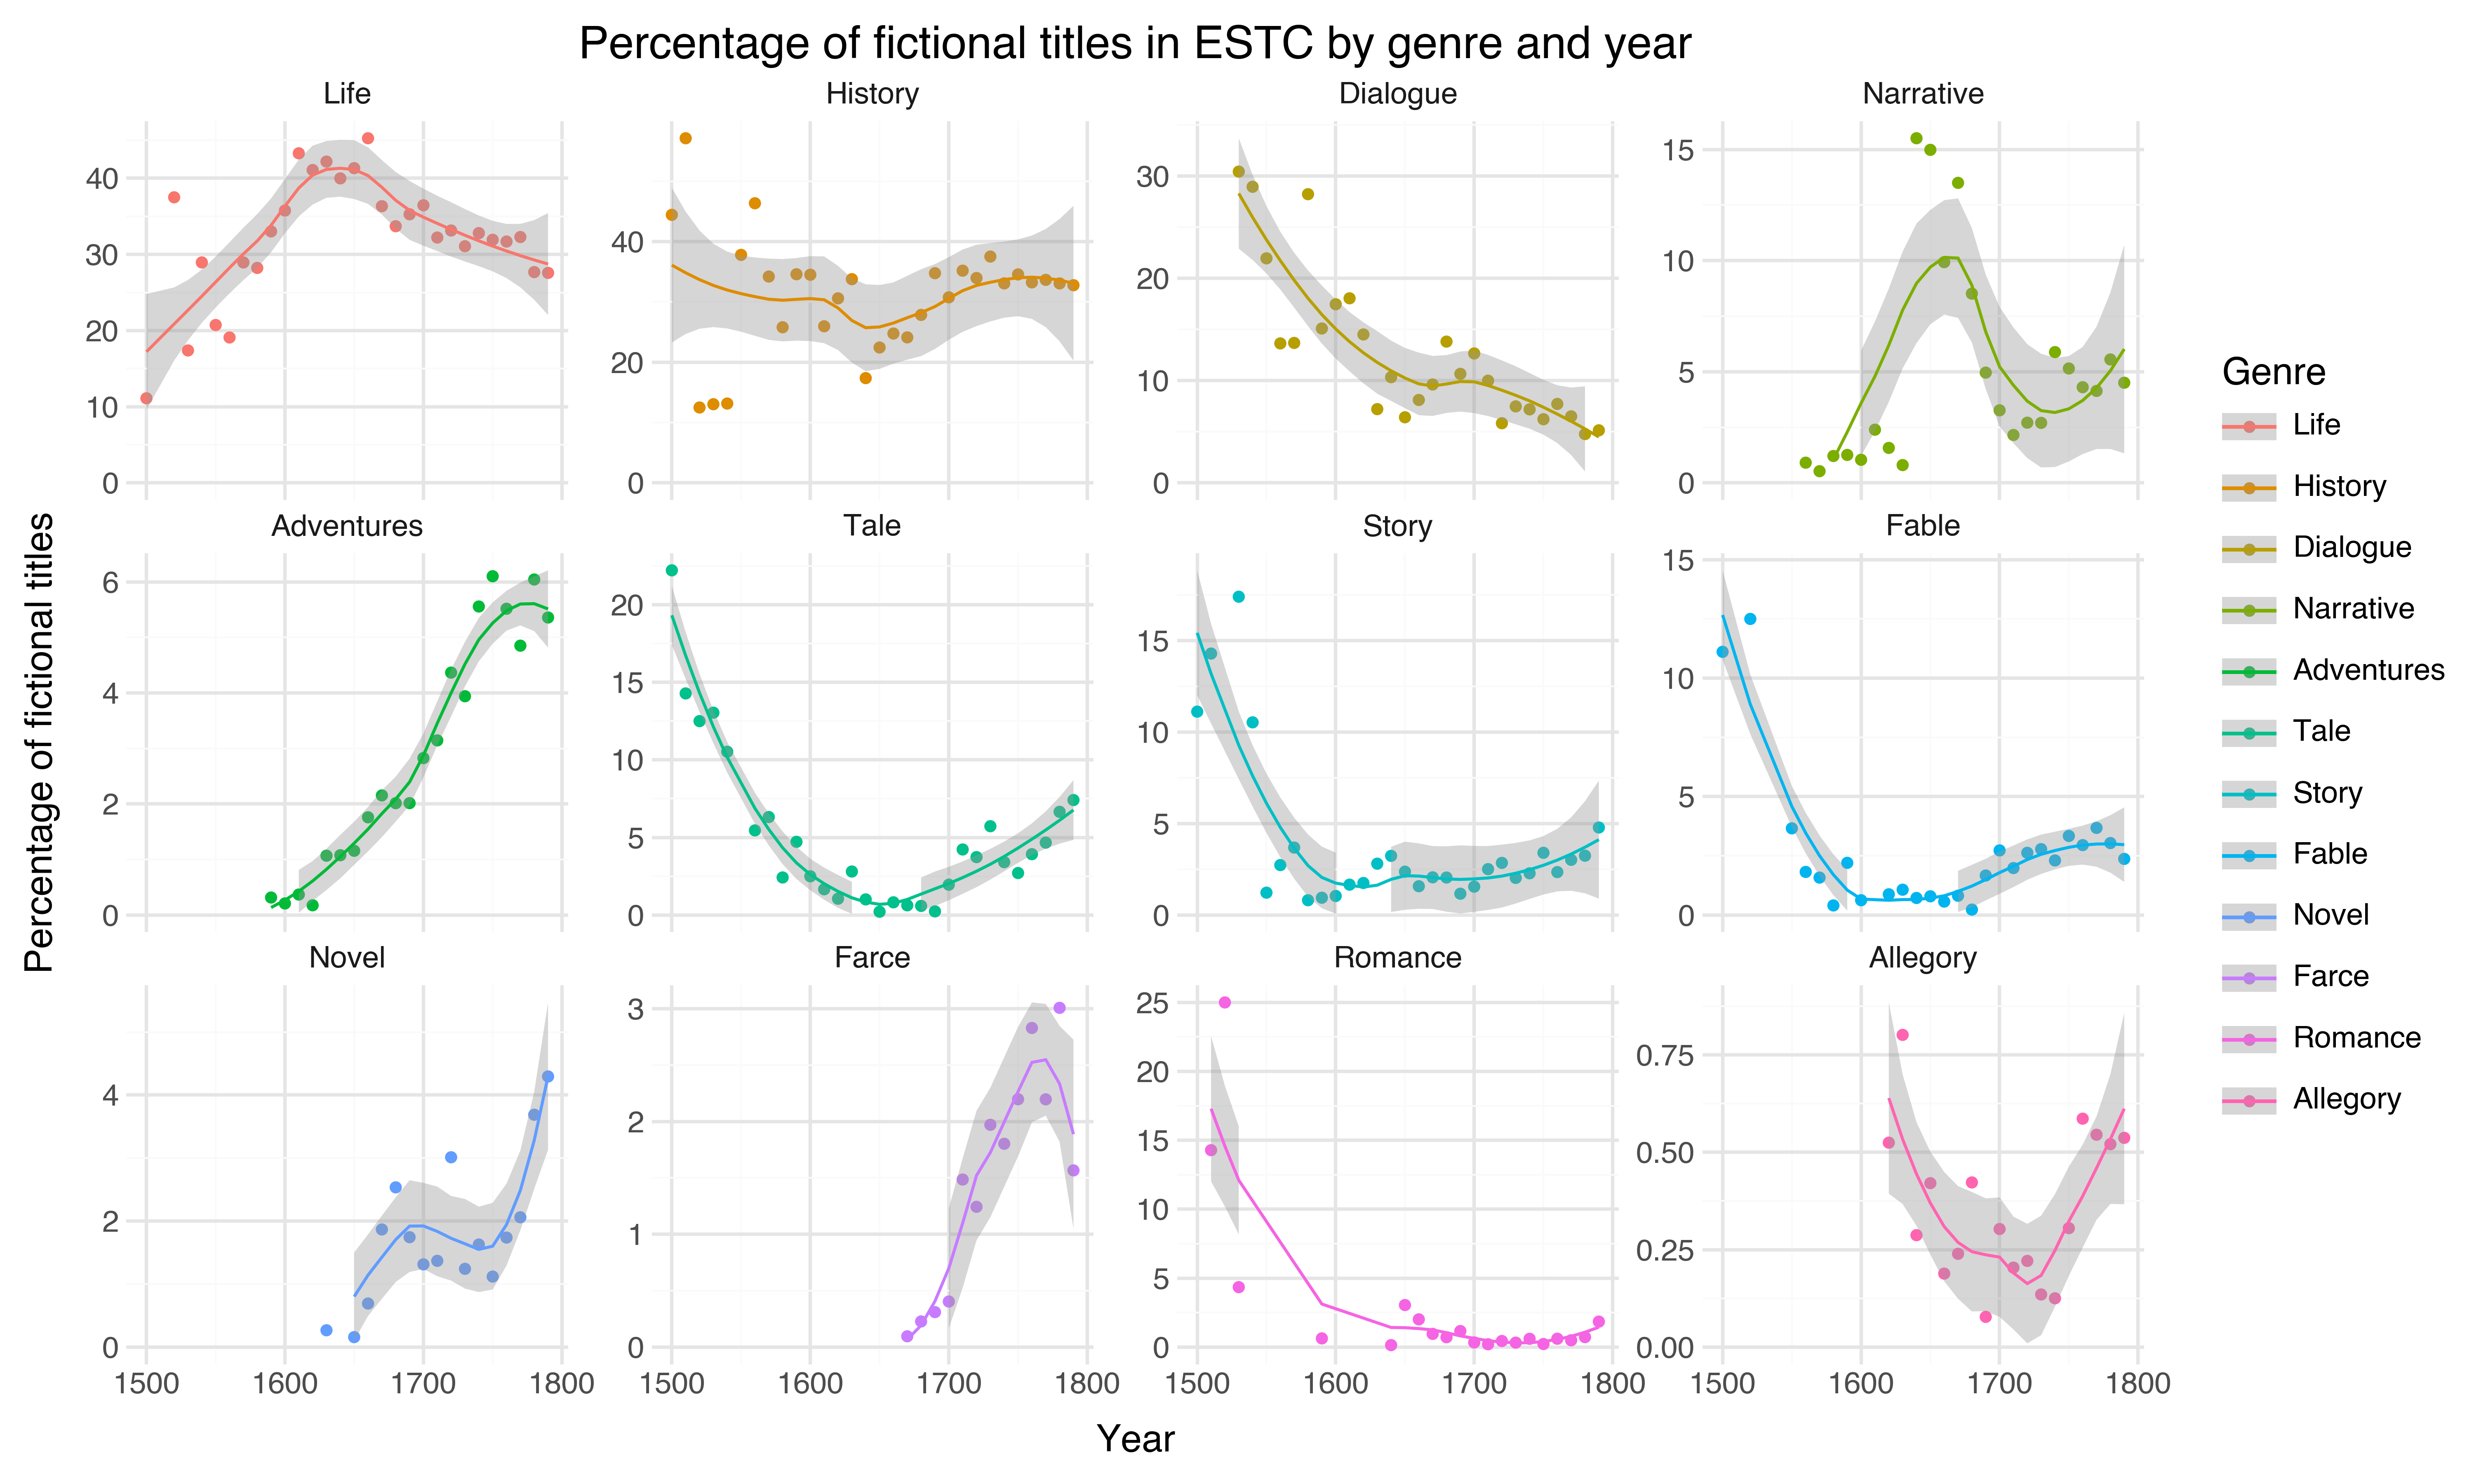

In [371]:
fig = (
    p9.ggplot(figdf.query('count>0'), p9.aes(x=yearcol, y='pct', color='genre_genre'))
    + p9.geom_point(size=1)
    # + p9.geom_line(size=.5)
    + p9.geom_smooth(method='loess', size=.5)
    + p9.theme_minimal()
    + p9.scale_color_discrete(name='Genre')
    + p9.facet_wrap('~genre_genre', scales='free_y')
    # + p9.facet_wrap('~genre_genre')
    # + p9.scale_y_log10()
    + p9.scale_y_continuous(limits=[0,None])
    + p9.labs(
        x='Year',
        y='Percentage of fictional titles',
        title='Percentage of fictional titles in ESTC by genre and year'
    )
)
fig

_llp_                                                                                                                                                                estc|000/N023416
author                                                                                                                                                                               
author_dates                                                                                                                                                                         
book_dimensions                                                                                                                                                                   12⁰
book_dimensions_standard                                                                                                                                                            2
book_extent                                                                               

In [375]:
df_ecco = pd.read_csv('/Volumes/diderot/lltk_data/corpora/ecco/metadata.csv').fillna('')

/var/folders/d9/tm2sn8_12xsc6p6nfgtrd5h40000gp/T/ipykernel_92499/1113889450.py:1: DtypeWarning: Columns (22,23) have mixed types. Specify dtype option on import or set low_memory=False.


In [376]:
df_eebo = pd.read_csv('/Volumes/diderot/lltk_data/corpora/eebo/metadata.csv').fillna('')

/var/folders/d9/tm2sn8_12xsc6p6nfgtrd5h40000gp/T/ipykernel_92499/3497787454.py:1: DtypeWarning: Columns (10,13) have mixed types. Specify dtype option on import or set low_memory=False.


In [379]:
df_eebo.iloc[0]

_llp_                                                                   eebo_tcp|A00001
author                                                                    A., fl. 1593.
corpus                                                                         EEBO-TCP
date                                                                              1593]
extent                                                                       [68] p.   
fnfn_xml            /Volumes/Present/DH/corpora/eebo/_xml_eebo_tcp/A00001.headed.xml.gz
genre                                                                             Prose
id                                                                               A00001
id_eebo_citation                                                             99851000.0
id_oclc                                                                                
id_proquest                                                                  99851000.0
id_rlin                         